### Import libraries ###


In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load the Dataset ###

In [2]:
file = "diabetes.csv"

df = pd.read_csv(file)
df.shape

(768, 9)

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [5]:
df['Outcome'].value_counts()
df['Outcome'].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

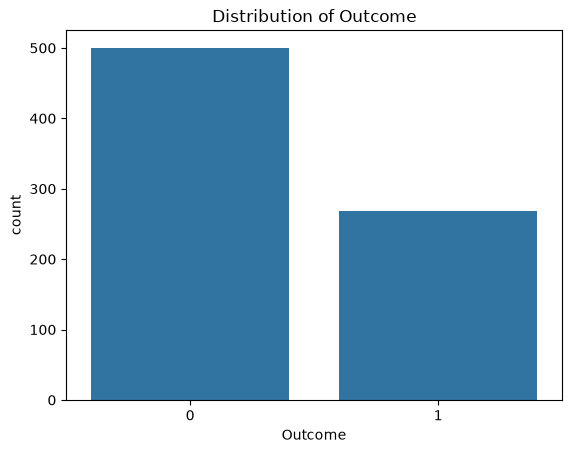

In [6]:
sns.countplot(x='Outcome', data=df)
plt.title('Distribution of Outcome')
plt.show()

In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [11]:
columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Count of Zero in each column: ")
for column in columns:
    print(column, (df[column] == 0).sum())

Count of Zero in each column: 
Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


### 2. Data Understanding ###

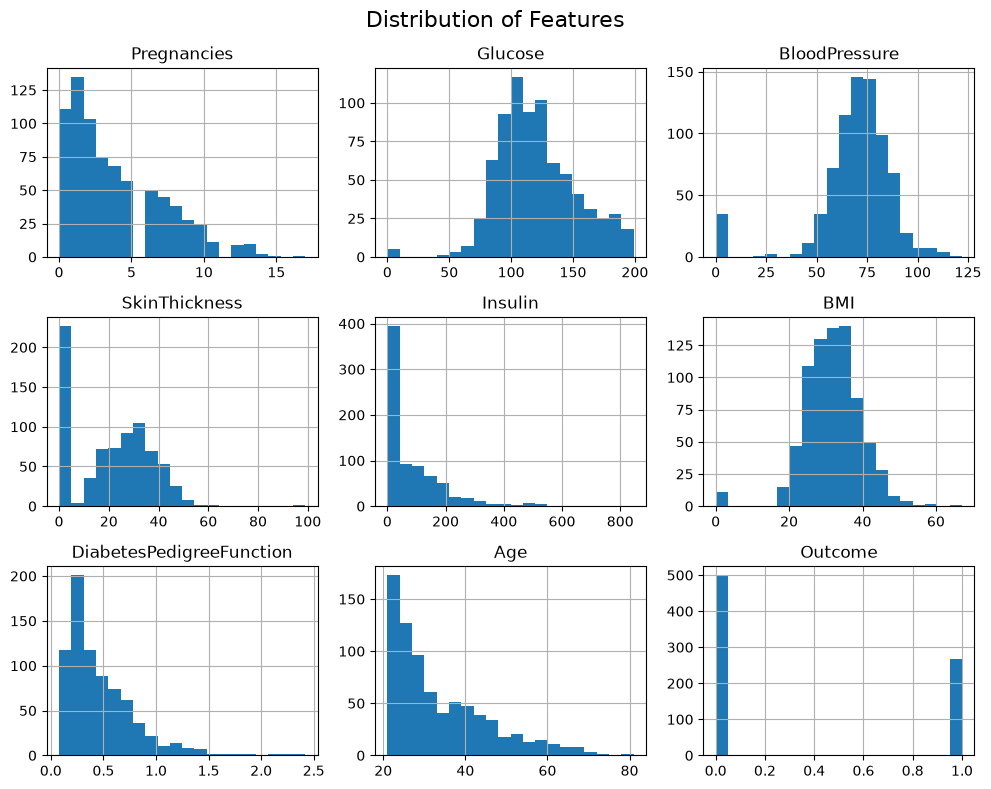

In [12]:
df.hist(figsize=(10, 8), bins=20)

plt.suptitle("Distribution of Features", fontsize=16)
plt.tight_layout()
plt.show()

#### Alternative plot ####

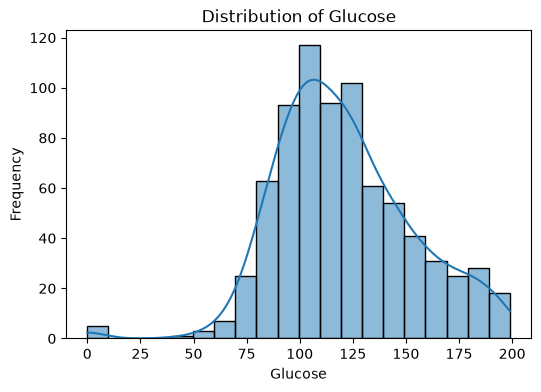

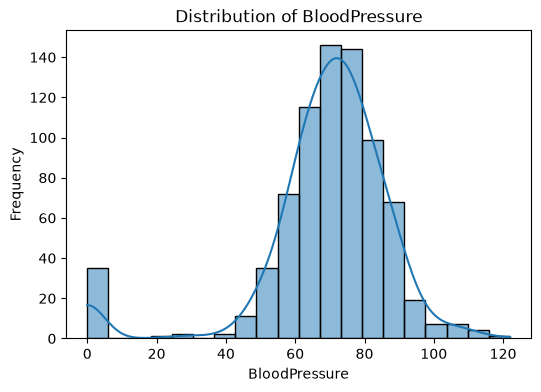

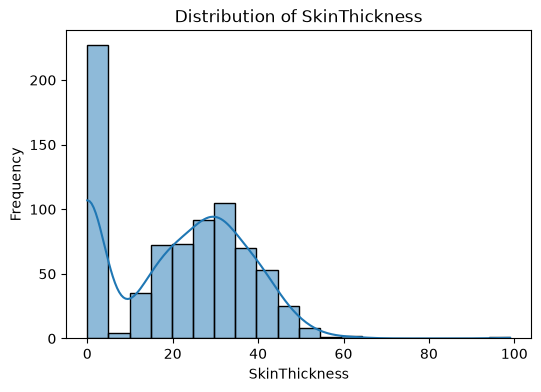

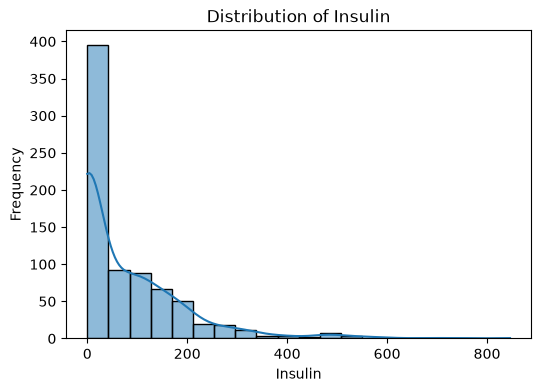

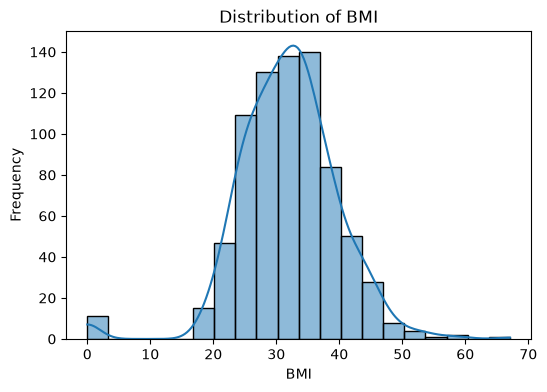

In [13]:
for column in columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[column],kde=True, bins=20)
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {column}')
    plt.show()

### Boxplots (Outlier Detection) ###

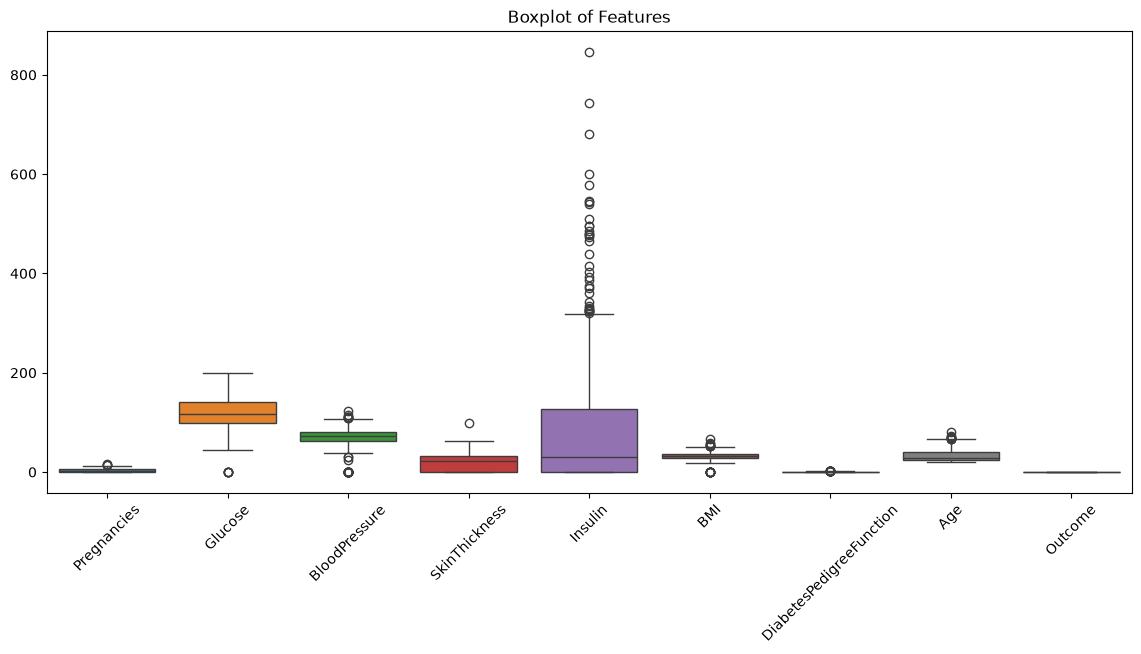

In [14]:
plt.figure(figsize=(14, 6))

sns.boxplot(data=df)

plt.xticks(rotation=45)
plt.title('Boxplot of Features')
plt.show()

### Compare Diabetic vs Non-Diabetic Patients ###

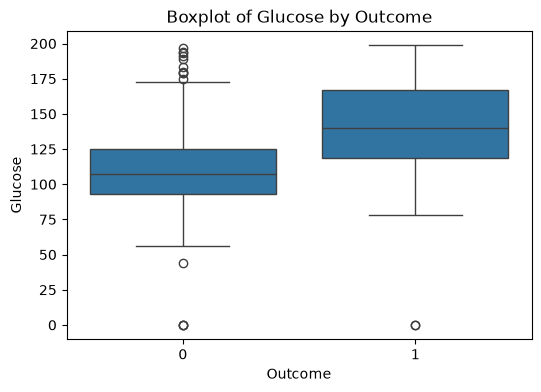

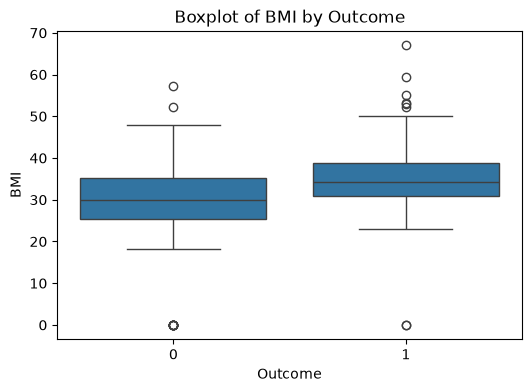

In [15]:
plt.figure(figsize=(6, 4))

sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title('Boxplot of Glucose by Outcome')
plt.show()

# BMI vs Outcome
plt.figure(figsize=(6, 4))
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title('Boxplot of BMI by Outcome')
plt.show()

### Correlation Heatmap (Most important plot) ###

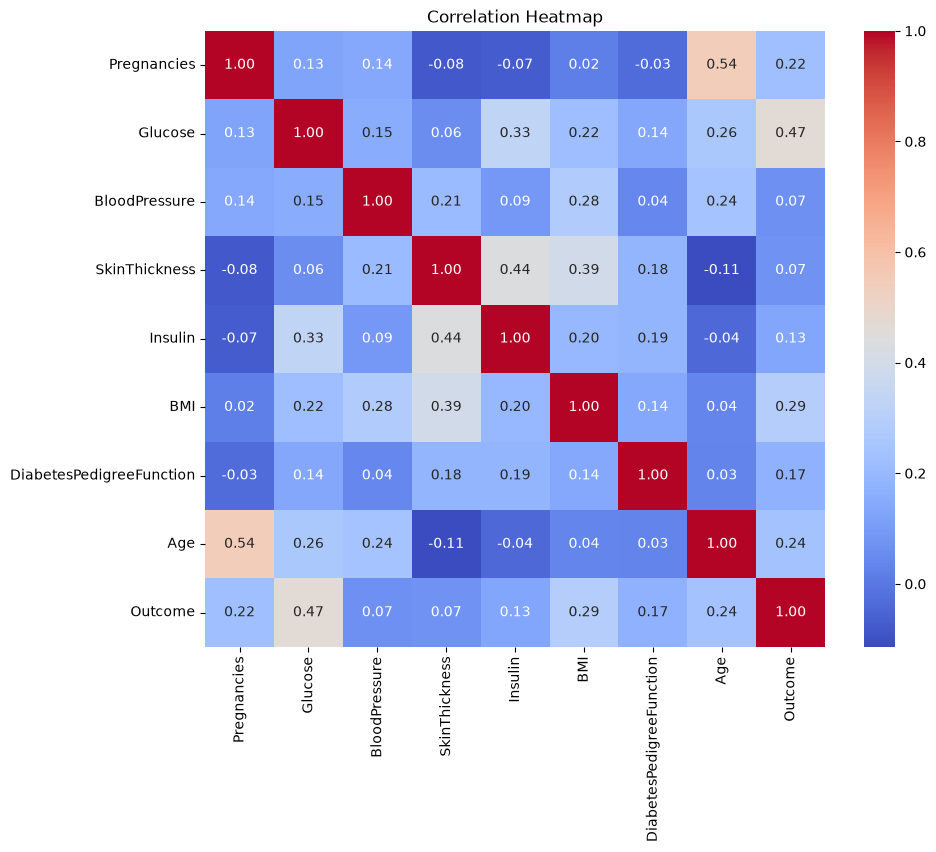

In [16]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### 3. Data Preprocessing ###

In [18]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features and target FIRST (no preprocessing yet)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("Features (X) shape:", X.shape)
print("Target variable (y) shape:", y.shape)

# 2. Split BEFORE any preprocessing 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# stratify=y ensures class distribution is similar in both sets
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

# 3. Replace zeros with NaN (fit on train only) 
columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

X_train[columns] = X_train[columns].replace(0, np.nan)
X_test[columns]  = X_test[columns].replace(0, np.nan)

print("Missing values in X_train:\n", X_train.isnull().sum())
print("Missing values in X_test:\n",  X_test.isnull().sum())

# 4. Impute using median from TRAIN only 
imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)  # ← transform only, no fit

print("After imputing - Missing in X_train:", X_train.isnull().sum().sum())
print("After imputing - Missing in X_test:",  X_test.isnull().sum().sum())

# 5. Scale using stats from TRAIN only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # ← transform only, no fit
# we don't fit the scaler on test set to prevent data leakage

# 6. Verify scaling 
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
# mean should be close to 0 and std close to 1
X_train_scaled_df.describe()

Features (X) shape: (768, 8)
Target variable (y) shape: (768,)
Missing values in X_train:
 Pregnancies                   0
Glucose                       4
BloodPressure                23
SkinThickness               175
Insulin                     290
BMI                           9
DiabetesPedigreeFunction      0
Age                           0
dtype: int64
Missing values in X_test:
 Pregnancies                  0
Glucose                      1
BloodPressure               12
SkinThickness               52
Insulin                     84
BMI                          2
DiabetesPedigreeFunction     0
Age                          0
dtype: int64
After imputing - Missing in X_train: 0
After imputing - Missing in X_test: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02,6.140000e+02
mean,-6.943414e-17,-1.099374e-16,3.095606e-16,-3.471707e-17,-4.339634e-18,1.649061e-16,-1.099374e-16,-1.084908e-16
std,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00,1.000815e+00
min,-1.153338e+00,-2.190541e+00,-3.924957e+00,-2.480958e+00,-1.559139e+00,-2.089621e+00,-1.192094e+00,-1.045895e+00
25%,-8.513551e-01,-7.562208e-01,-6.636760e-01,-4.549828e-01,-2.249692e-01,-7.073644e-01,-7.042617e-01,-7.921693e-01
50%,-2.473897e-01,-1.558076e-01,-1.141979e-02,-4.766137e-03,-1.614373e-01,-7.070181e-03,-2.876344e-01,-3.692933e-01
75%,6.585583e-01,6.113872e-01,6.408364e-01,3.328964e-01,-9.790537e-02,5.942296e-01,4.903223e-01,6.456090e-01
max,3.980368e+00,2.579408e+00,4.065181e+00,7.874025e+00,7.703814e+00,5.081979e+00,5.610293e+00,4.028617e+00


### 4. Model Development ###


In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay



#### Random Forest ####

In [20]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(rf, rf_params, cv=10, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Contro

#### KNN ####

In [21]:
knn = KNeighborsClassifier()
knn_params = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance']
}
# Grid Search to find the best hyperparameters for KNN
# Roc AUC is used as the scoring metric because it is more informative for imbalanced datasets, as it considers both the true positive rate and false positive rate across different thresholds.
knn_grid = GridSearchCV(estimator=knn, param_grid=knn_params, cv=10, n_jobs=-1, scoring='roc_auc')

knn_grid.fit(X_train_scaled, y_train)

print("Best parameters for KNN:", knn_grid.best_params_)

knn_best = knn_grid.best_estimator_
y_pred_knn = knn_best.predict(X_test_scaled)

print("Classification Report for KNN:")
print(classification_report(y_test, y_pred_knn))

print("Confusion Matrix for KNN:")
print(confusion_matrix(y_test, y_pred_knn))

Best parameters for KNN: {'n_neighbors': 24, 'weights': 'distance'}
Classification Report for KNN:
              precision    recall  f1-score   support

           0       0.78      0.86      0.82       100
           1       0.68      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154

Confusion Matrix for KNN:
[[86 14]
 [24 30]]


#### Support Vector Machine (SVM)

In [22]:
svm = SVC(probability=True, class_weight = 'balanced') 
# Hyperparameters to tune for SVM
svm_params = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C' : [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto']
}

# Grid Search to find the best hyperparameters for SVM
svm_grid = GridSearchCV(estimator=svm, param_grid=svm_params, cv=10, n_jobs=-1 , scoring='roc_auc')
svm_grid.fit(X_train_scaled, y_train)

print("Best SVM Parameters: ", svm_grid.best_params_)

svm_best = svm_grid.best_estimator_
y_pred_svm = svm_best.predict(X_test_scaled)
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix for SVM")
print(confusion_matrix(y_test, y_pred_svm))


Best SVM Parameters:  {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
              precision    recall  f1-score   support

           0       0.82      0.74      0.78       100
           1       0.59      0.70      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154

Confusion Matrix for SVM
[[74 26]
 [16 38]]


c:\Users\Gebruiker\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


#### Neural Netwrok (NN) ####

In [23]:
# Apply SMOTE to balance the training data before fitting MLP
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

# Expanded MLP with better hyperparameters
mlp = MLPClassifier(random_state=42, max_iter=2000, early_stopping=True)

mlp_params = {
    "hidden_layer_sizes": [(50,), (100,), (50, 50), (100, 50), (100, 100)],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
    "activation": ["relu", "tanh"]
}

mlp_grid = GridSearchCV(mlp, mlp_params, scoring='roc_auc', cv=10, n_jobs=-1)

# Train on the SMOTE-balanced data instead of original
mlp_grid.fit(X_train_res, y_train_res)

print("Best Neural Network Parameters:")
print(mlp_grid.best_params_)

mlp_best = mlp_grid.best_estimator_
y_pred_mlp = mlp_best.predict(X_test_scaled)

print(classification_report(y_test, y_pred_mlp))
print("Confusion Matrix for NN:")
print(confusion_matrix(y_test, y_pred_mlp))

Before SMOTE: {0: 400, 1: 214}
After SMOTE: {0: 400, 1: 400}
Best Neural Network Parameters:
{'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.01}
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       100
           1       0.69      0.65      0.67        54

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.75       154
weighted avg       0.77      0.77      0.77       154

Confusion Matrix for NN:
[[84 16]
 [19 35]]


#### Compare All Models ####

         Model  Accuracy  Precision  Recall     F1  ROC-AUC
           KNN    0.7532     0.6818  0.5556 0.6122   0.8100
           SVM    0.7273     0.5938  0.7037 0.6441   0.8065
Neural Network    0.7727     0.6863  0.6481 0.6667   0.8337
 Random Forest    0.7338     0.6585  0.5000 0.5684   0.8139

 Best model by ROC-AUC: Neural Network


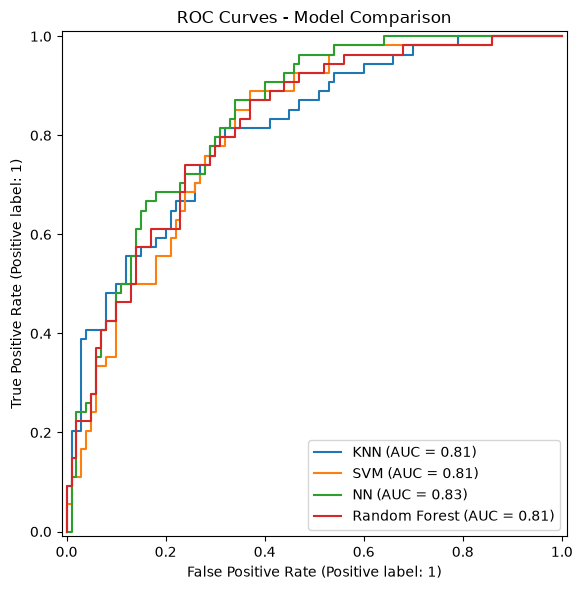

In [24]:
# --- 1. Predictions for all models ---
y_pred_knn = knn_best.predict(X_test_scaled)
y_pred_svm = svm_best.predict(X_test_scaled)
y_pred_mlp = mlp_best.predict(X_test_scaled)
y_pred_rf  = rf_grid.best_estimator_.predict(X_test_scaled)

# --- 2. Probabilities for ROC-AUC ---
knn_prob = knn_best.predict_proba(X_test_scaled)[:, 1]
svm_prob = svm_best.predict_proba(X_test_scaled)[:, 1]
mlp_prob = mlp_best.predict_proba(X_test_scaled)[:, 1]
rf_prob  = rf_grid.best_estimator_.predict_proba(X_test_scaled)[:, 1]

# --- 3. Full comparison table ---
results = pd.DataFrame({
    "Model": ["KNN", "SVM", "Neural Network", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_mlp),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_mlp),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_mlp),
        recall_score(y_test, y_pred_rf)
    ],
    "F1": [
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_mlp),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, knn_prob),
        roc_auc_score(y_test, svm_prob),
        roc_auc_score(y_test, mlp_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

# Round for cleaner display
results = results.round(4)
print(results.to_string(index=False))

# --- 4. Highlight best model ---
best_model = results.loc[results["ROC-AUC"].idxmax(), "Model"]
print(f"\n Best model by ROC-AUC: {best_model}")

# --- 5. ROC Curve plot for all models ---
fig, ax = plt.subplots(figsize=(8, 6))
for name, probs in [("KNN", knn_prob), ("SVM", svm_prob), ("NN", mlp_prob), ("Random Forest", rf_prob)]:
    RocCurveDisplay.from_predictions(y_test, probs, name=name, ax=ax)

plt.title("ROC Curves - Model Comparison")
plt.tight_layout()
plt.show()

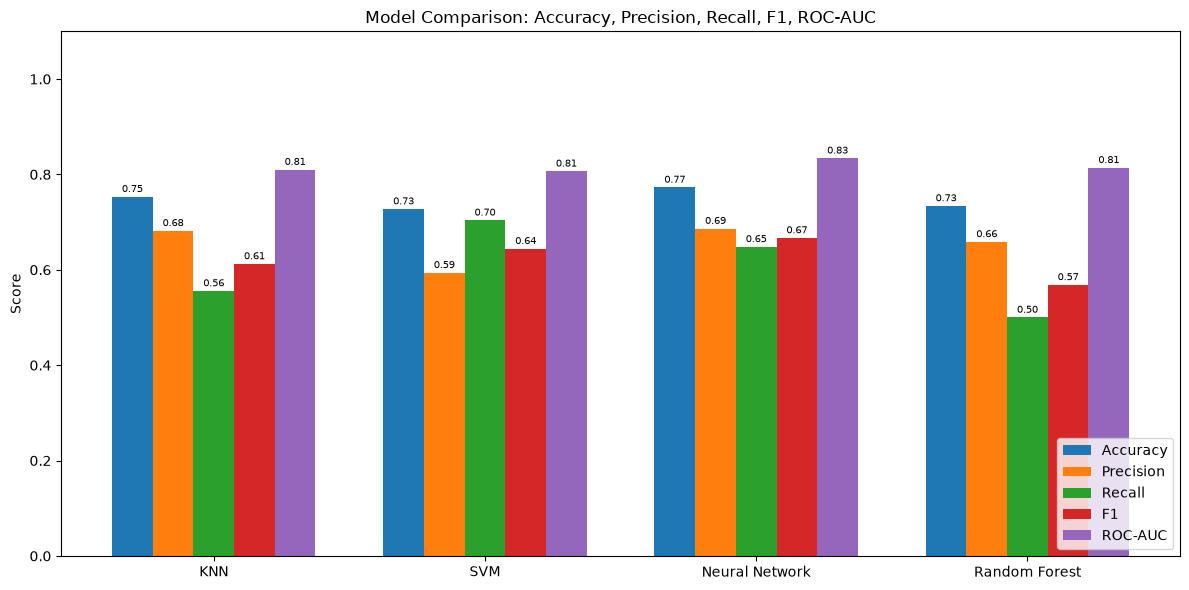

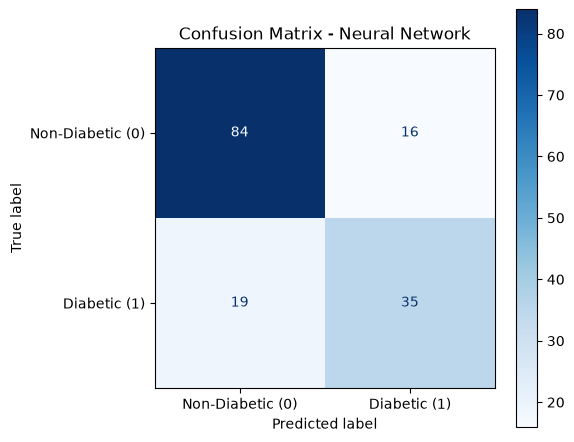

In [28]:
# --- 1. Grouped Bar Chart: Accuracy, Precision, Recall, F1, ROC-AUC ---
models = results["Model"].tolist()
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

x = np.arange(len(models))
width = 0.15  # width of each bar

fig, ax = plt.subplots(figsize=(12, 6))

for i, metric in enumerate(metrics):
    values = results[metric].tolist()
    bars = ax.bar(x + i * width, values, width, label=metric)
    # Add value labels on top of each bar
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.2f}",
            ha='center', va='bottom', fontsize=7
        )

ax.set_xticks(x + width * 2)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Model Comparison: Accuracy, Precision, Recall, F1, ROC-AUC")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


# --- 2. Confusion Matrix for Neural Network ---
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_mlp,
    display_labels=["Non-Diabetic (0)", "Diabetic (1)"],
    cmap="Blues",
    ax=ax
)

ax.set_title("Confusion Matrix - Neural Network")
plt.tight_layout()
plt.show()